# 🛡️ InstaGuard AI — Behavior Analysis Engine
## Stage 3: Post-Tracking Intelligence Layer

```
Pipeline:
  [Stage 1] YOLOv8s Training      ← yolov8s-single-model-training.ipynb
  [Stage 2] Detection + Tracking  ← deepsort_tracking_colab_images.ipynb
  [Stage 3] Behavior Analysis     ← THIS NOTEBOOK ✅
```

| Module | Description |
|--------|-------------|
| 🔄 Class Transition Analysis | Detects per-track state changes (Normal → Product-Picked → Theft) |
| ⏱️ Dwell Time Analysis | Flags tracks that linger suspiciously long |
| 🧳 Concealment Detection | Product-Picked appears while product count drops |
| 🔥 Spatial Heatmap | Maps where suspicious activity concentrates |
| 🚨 Risk Scoring Engine | Assigns 0–100 threat score per tracked entity |
| 📋 Alert Report | Exportable JSON + CSV alert log |

> 👉 **Runtime → Change Runtime Type → T4 GPU** before running!


---
## 1. Install Dependencies


In [ ]:
!pip install -q ultralytics boxmot gdown opencv-python seaborn pandas matplotlib scipy
print('\n✅ Dependencies installed')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 21.7 MB/s eta 0:00:00

✅ Dependencies installed


---
## 2. Mount Google Drive & Verify Inputs


In [ ]:
import os

# ✅ No Drive needed — downloading directly by public file ID
WEIGHTS_PATH      = '/content/results.zip'
DATASET_ZIP_DRIVE = '/content/dataset.zip'
SPLIT             = 'test'

print('✅ Config ready — will download files directly via gdown')
print('   No Drive mount needed!')

✅ Config ready — will download files directly via gdown
   No Drive mount needed!


---
## 3. Imports & Global Configuration


In [ ]:
import os, re, json, time, cv2, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
from pathlib import Path
from importlib import import_module
from scipy.ndimage import gaussian_filter
import torch
from ultralytics import YOLO

# ── Class definitions (must match training)
CLASS_NAMES = {
    0: 'Customer-Bagpack',
    1: 'Product',
    2: 'Product-Picked',
    3: 'Shopping-Cart',
    4: 'Normal',
    5: 'Theft'
}

CLASS_COLORS = {
    0: '#4A90D9',
    1: '#7ED321',
    2: '#F5A623',
    3: '#9B59B6',
    4: '#2ECC71',
    5: '#E74C3C',
}

# ✏️ Behavior thresholds — tune based on your frame rate
LOITER_FRAME_THRESHOLD  = 30   # frames without moving > LOITER_DIST pixels
LOITER_DIST_THRESHOLD   = 50   # pixel movement threshold
CONCEALMENT_GAP_FRAMES  = 15   # frames after Product-Picked to watch for product drop
HIGH_DWELL_FRAMES       = 50   # tracks seen in more than this many frames
ZONE_GRID_ROWS          = 4
ZONE_GRID_COLS          = 4

# Risk score weights (sum = 100)
RISK_WEIGHTS = {
    'theft_class_seen': 45,
    'product_picked':   20,
    'theft_sequence':   20,
    'concealment':      10,
    'loitering':         5,
}

OUTPUT_DIR = '/content/behavior_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Configuration loaded')
print(f'   Classes  : {list(CLASS_NAMES.values())}')
print(f'   Output   : {OUTPUT_DIR}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Configuration loaded
   Classes  : ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'Normal', 'Theft']
   Output   : /content/behavior_analysis


---
## 4. Load Model & Images
> Same setup as Stage 2 — extract `best.pt` and dataset images.


In [ ]:
import zipfile, gdown

# ── Extract best.pt
os.makedirs('/content/model', exist_ok=True)
RESULTS_ZIP_FILE_ID = '1hzc8RME5QumeYQLTiq3ac9RTM2SzkUhh'  # ✏️ same as Stage 2

if os.path.exists(WEIGHTS_PATH) and WEIGHTS_PATH.endswith('.pt'):
    PT_PATH = WEIGHTS_PATH
    print(f'✅ Using best.pt: {PT_PATH}')
else:
    zip_src = WEIGHTS_PATH if os.path.exists(WEIGHTS_PATH) else '/content/results.zip'
    if not os.path.exists(zip_src):
        gdown.download(f'https://drive.google.com/uc?id={RESULTS_ZIP_FILE_ID}',
                       zip_src, quiet=False, fuzzy=True)
    with zipfile.ZipFile(zip_src, 'r') as zf:
        pt_files = [f for f in zf.namelist() if f.endswith('best.pt')]
        zf.extract(pt_files[0], '/content/model/')
        PT_PATH = f'/content/model/{pt_files[0]}'

print(f'✅ Weights: {PT_PATH}  ({os.path.getsize(PT_PATH)/1e6:.1f} MB)')


Downloading...
From (original): https://drive.google.com/uc?id=1hzc8RME5QumeYQLTiq3ac9RTM2SzkUhh
From (redirected): https://drive.google.com/uc?id=1hzc8RME5QumeYQLTiq3ac9RTM2SzkUhh&confirm=t&uuid=c76971d2-ff51-4c52-bb3c-95acb004d156
To: /content/results.zip
100%|██████████| 6.37G/6.37G [01:00<00:00, 105MB/s] 


✅ Weights: /content/model/yolo_small/yolov8s/weights/best.pt  (22.5 MB)


In [ ]:
# ── Extract dataset images
IMAGES_DIR = f'/content/dataset/{SPLIT}/images'
os.makedirs(IMAGES_DIR, exist_ok=True)

DATASET_ZIP_FILE_ID = '1dK16BAmZXpXCvazsWgI73OQ7_ts8-PfX'  # ✏️ same as Stage 2
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

DS_ZIP = DATASET_ZIP_DRIVE if os.path.exists(DATASET_ZIP_DRIVE) else '/content/dataset.zip'
if not os.path.exists(DS_ZIP):
    gdown.download(f'https://drive.google.com/uc?id={DATASET_ZIP_FILE_ID}',
                   DS_ZIP, quiet=False, fuzzy=True)

print(f'📦 Extracting {SPLIT}/images ...')
with zipfile.ZipFile(DS_ZIP, 'r') as zf:
    members = [m for m in zf.namelist()
               if f'{SPLIT}/images' in m and Path(m).suffix.lower() in IMG_EXTS]
    for m in members:
        dest = os.path.join(IMAGES_DIR, Path(m).name)
        if not os.path.exists(dest):
            with zf.open(m) as src, open(dest, 'wb') as dst:
                dst.write(src.read())

all_images = sorted([os.path.join(IMAGES_DIR, f)
                     for f in os.listdir(IMAGES_DIR)
                     if Path(f).suffix.lower() in IMG_EXTS])
print(f'✅ {len(all_images)} images ready')


Downloading...
From (original): https://drive.google.com/uc?id=1dK16BAmZXpXCvazsWgI73OQ7_ts8-PfX
From (redirected): https://drive.google.com/uc?id=1dK16BAmZXpXCvazsWgI73OQ7_ts8-PfX&confirm=t&uuid=015195e5-bc80-457a-9e61-575cf847a5de
To: /content/dataset.zip
100%|██████████| 3.15G/3.15G [00:35<00:00, 89.9MB/s]


📦 Extracting test/images ...
✅ 740 images ready


---
## 5. Detection + Tracking (with Full Behavior Data Collection)
> Runs YOLOv8 + ByteTrack and captures **per-frame, per-track positions**
> needed for trajectory, loitering, and heatmap analysis.


In [ ]:
# Load track_history from Notebook 2
with open('/content/track_history.json', 'r') as f:
    track_history_loaded = json.load(f)

track_history = defaultdict(list)
for k, v in track_history_loaded.items():
    track_history[int(k)] = v

# Set TOTAL
TOTAL = max((max(entry['frame_idx'] for entry in track) for track in track_history.values() if track), default=0) + 1

print(f'✅ Loaded {len(track_history)} tracks from {TOTAL} frames')

# Build frame_data from track_history
frame_data = []
for frame_idx in range(TOTAL):
    frame_tracks = []
    raw_cls_count = Counter()
    for track_id, entries in track_history.items():
        for entry in entries:
            if entry['frame_idx'] == frame_idx:
                frame_tracks.append(entry)
                raw_cls_count[entry['cls_id']] += 1
    frame_data.append({
        'frame_idx': frame_idx,
        'tracks': frame_tracks,
        'n_detections': len(frame_tracks),
        'raw_classes': raw_cls_count,
    })

print(f'✅ Built frame_data for {len(frame_data)} frames')


✅ YOLOv8 ready on cuda


SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30


🚀 Processing 740 images ...



SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0

  [ 100/740]  28.9 img/s  | Unique tracks: 44


...

  [ 600/740]  53.2 img/s  | Unique tracks: 135


SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30


  [ 700/740]  54.8 img/s  | Unique tracks: 138


SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0.8, track_buffer=25, frame_rate=30
SUCCESS  | ByteTrack: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False, asso_func=iou, min_conf=0.1, track_thresh=0.45, match_thresh=0

  [ 740/740]  55.1 img/s  | Unique tracks: 147

✅ Done!  147 unique tracks across 740 frames


---
## 6. Build Track Profiles


In [ ]:
def build_track_profiles(track_history):
    profiles = {}
    for tid, frames in track_history.items():
        frames_sorted  = sorted(frames, key=lambda x: x['frame_idx'])
        class_seq      = [(f['frame_idx'], f['cls_name']) for f in frames_sorted]
        classes_seen   = Counter(f['cls_name'] for f in frames_sorted)
        dominant_class = classes_seen.most_common(1)[0][0]
        trajectory     = [(f['frame_idx'], f['cx'], f['cy']) for f in frames_sorted]
        dwell_frames   = len(frames_sorted)
        product_picked = [f for f in frames_sorted if f['cls_name'] == 'Product-Picked']
        fw = frames_sorted[0].get('frame_width', 1920)
        fh = frames_sorted[0].get('frame_height', 1080)
        profiles[tid] = {
            'track_id': tid,
            'dwell_frames': dwell_frames,
            'first_frame': frames_sorted[0]['frame_idx'],
            'last_frame': frames_sorted[-1]['frame_idx'],
            'classes_seen': dict(classes_seen),
            'dominant_class': dominant_class,
            'class_sequence': class_seq,
            'trajectory': trajectory,
            'product_picked_frames': product_picked,
            'frame_width': fw,
            'frame_height': fh,
            'sequence_name': frames_sorted[0]['sequence'],
        }
    return profiles

track_profiles = build_track_profiles(track_history)
print(f'✅ Built {len(track_profiles)} track profiles')


✅ Built 147 track profiles


---
## 7. Behavior Detection Engine


In [ ]:
# ────────────────────────────────────────────────────────────────
# Detector 1: Theft Sequence  (Normal → Product-Picked → Theft)
# ────────────────────────────────────────────────────────────────
def detect_theft_sequence(profile):
    seq    = profile['class_sequence']
    stages = {'Normal': None, 'Product-Picked': None, 'Theft': None}
    for frame_idx, cls_name in seq:
        if cls_name in stages and stages[cls_name] is None:
            stages[cls_name] = frame_idx
    if all(v is not None for v in stages.values()):
        if stages['Normal'] < stages['Product-Picked'] < stages['Theft']:
            return True, stages
    return False, stages


# ────────────────────────────────────────────────────────────────
# Detector 2: Loitering
# ────────────────────────────────────────────────────────────────
def detect_loitering(profile):
    traj = profile['trajectory']
    if len(traj) < LOITER_FRAME_THRESHOLD:
        return False, 0
    max_loiter = current_loiter = 1
    anchor_x, anchor_y = traj[0][1], traj[0][2]
    for _, cx, cy in traj[1:]:
        dist = ((cx - anchor_x)**2 + (cy - anchor_y)**2) ** 0.5
        if dist <= LOITER_DIST_THRESHOLD:
            current_loiter += 1
        else:
            max_loiter = max(max_loiter, current_loiter)
            current_loiter = 1
            anchor_x, anchor_y = cx, cy
    max_loiter = max(max_loiter, current_loiter)
    return max_loiter >= LOITER_FRAME_THRESHOLD, max_loiter


# ────────────────────────────────────────────────────────────────
# Detector 3: Concealment
# ────────────────────────────────────────────────────────────────
def detect_concealment(profile, frame_data_list):
    if not profile['product_picked_frames']:
        return False, None
    for pp_entry in profile['product_picked_frames']:
        pp_idx       = pp_entry['frame_idx']
        before_count = pp_entry.get('raw_products_in_frame', 0)
        for fd in frame_data_list:
            if pp_idx < fd['frame_idx'] <= pp_idx + CONCEALMENT_GAP_FRAMES:
                after_count = fd['raw_classes'].get(1, 0)
                if before_count > 0 and after_count < before_count:
                    return True, fd['frame_idx']
    return False, None


# ────────────────────────────────────────────────────────────────
# Risk Scorer
# ────────────────────────────────────────────────────────────────
def compute_risk_score(profile, theft_seq, loiter, concealment):
    score = 0
    breakdown = {}
    if 'Theft' in profile['classes_seen']:
        score += RISK_WEIGHTS['theft_class_seen']
        breakdown['theft_class_seen'] = RISK_WEIGHTS['theft_class_seen']
    has_pp = 'Product-Picked' in profile['classes_seen']
    has_sc = 'Shopping-Cart'  in profile['classes_seen']
    if has_pp and not has_sc:
        score += RISK_WEIGHTS['product_picked']
        breakdown['product_picked'] = RISK_WEIGHTS['product_picked']
    if theft_seq:
        score += RISK_WEIGHTS['theft_sequence']
        breakdown['theft_sequence'] = RISK_WEIGHTS['theft_sequence']
    if concealment:
        score += RISK_WEIGHTS['concealment']
        breakdown['concealment'] = RISK_WEIGHTS['concealment']
    if loiter:
        score += RISK_WEIGHTS['loitering']
        breakdown['loitering'] = RISK_WEIGHTS['loitering']
    return min(score, 100), breakdown


def risk_level(score):
    if score >= 70: return 'CRITICAL'
    if score >= 45: return 'HIGH'
    if score >= 20: return 'MEDIUM'
    return 'LOW'


print('✅ Behavior detectors defined')


✅ Behavior detectors defined


---
## 8. Run All Behavior Detectors


In [ ]:
analysis_results = []

for tid, profile in track_profiles.items():
    theft_seq, theft_stages   = detect_theft_sequence(profile)
    loiter, loiter_dur        = detect_loitering(profile)
    conceal, conceal_frame    = detect_concealment(profile, frame_data)
    risk_score, risk_breakdown = compute_risk_score(profile, theft_seq, loiter, conceal)

    analysis_results.append({
        'track_id':           tid,
        'sequence_name':      profile['sequence_name'],
        'dominant_class':     profile['dominant_class'],
        'classes_seen':       profile['classes_seen'],
        'dwell_frames':       profile['dwell_frames'],
        'high_dwell':         profile['dwell_frames'] > HIGH_DWELL_FRAMES,
        'theft_sequence':     theft_seq,
        'theft_stages':       theft_stages,
        'loitering':          loiter,
        'loiter_duration':    loiter_dur,
        'concealment':        conceal,
        'concealment_frame':  conceal_frame,
        'risk_score':         risk_score,
        'risk_level':         risk_level(risk_score),
        'risk_breakdown':     risk_breakdown,
        'first_frame':        profile['first_frame'],
        'last_frame':         profile['last_frame'],
        'trajectory':         profile['trajectory'],
        'frame_width':        profile['frame_width'],
        'frame_height':       profile['frame_height'],
    })

analysis_results.sort(key=lambda x: x['risk_score'], reverse=True)

df = pd.DataFrame([{k: v for k, v in r.items()
                    if k not in ('trajectory','theft_stages','risk_breakdown','classes_seen')}
                   for r in analysis_results])

print('=' * 60)
print('BEHAVIOR ANALYSIS SUMMARY')
print('=' * 60)
print(f'Total tracks     : {len(analysis_results)}')
print(f'Theft sequences  : {df["theft_sequence"].sum()}')
print(f'Loitering        : {df["loitering"].sum()}')
print(f'Concealment      : {df["concealment"].sum()}')
print(f'CRITICAL         : {(df["risk_level"]=="CRITICAL").sum()}')
print(f'HIGH             : {(df["risk_level"]=="HIGH").sum()}')
print(f'MEDIUM           : {(df["risk_level"]=="MEDIUM").sum()}')
print(f'LOW              : {(df["risk_level"]=="LOW").sum()}')
print('\nTop 10 riskiest tracks:')
print(df[['track_id','dominant_class','risk_score','risk_level',
           'theft_sequence','loitering','concealment','dwell_frames']].head(10).to_string(index=False))


BEHAVIOR ANALYSIS SUMMARY
Total tracks     : 147
Theft sequences  : 0
Loitering        : 1
Concealment      : 0
CRITICAL         : 0
HIGH             : 111
MEDIUM           : 0
LOW              : 36

Top 10 riskiest tracks:
 track_id dominant_class  risk_score risk_level  theft_sequence  loitering  concealment  dwell_frames
      138          Theft          50       HIGH           False       True        False            40
        1         Normal          45       HIGH           False      False        False             4
        6          Theft          45       HIGH           False      False        False             3
        7          Theft          45       HIGH           False      False        False             1
        8          Theft          45       HIGH           False      False        False             1
        9          Theft          45       HIGH           False      False        False             1
       10          Theft          45       HIGH           Fals

---
## 9. Visualizations
### 9.1 — Risk Overview


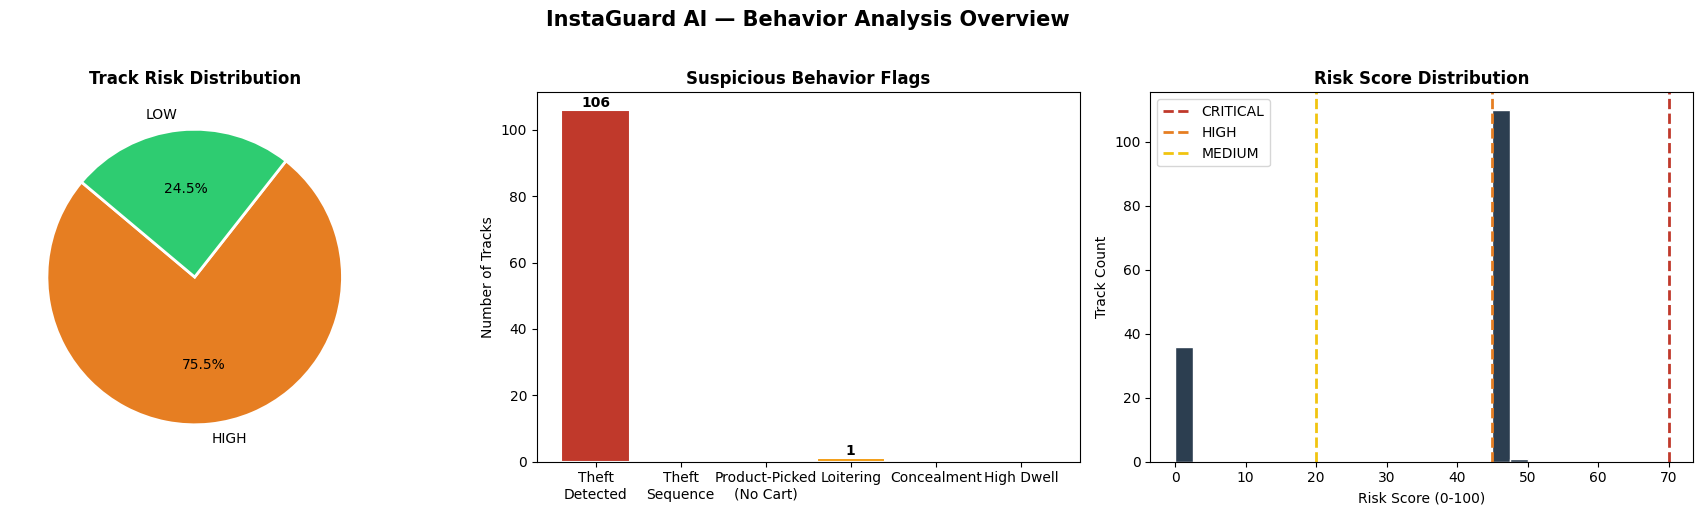

✅ Saved 01_behavior_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('InstaGuard AI — Behavior Analysis Overview',
             fontsize=15, fontweight='bold', y=1.02)

RISK_COLORS = {'CRITICAL': '#C0392B', 'HIGH': '#E67E22',
               'MEDIUM': '#F1C40F', 'LOW': '#2ECC71'}

# Pie chart
risk_counts = df['risk_level'].value_counts()
risk_order  = [r for r in ['CRITICAL','HIGH','MEDIUM','LOW'] if r in risk_counts]
axes[0].pie(
    [risk_counts[r] for r in risk_order],
    labels=risk_order,
    colors=[RISK_COLORS[r] for r in risk_order],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Track Risk Distribution', fontweight='bold')

# Behavior flag bar chart
behavior_flags = {
    'Theft\nDetected':       (df['dominant_class'] == 'Theft').sum(),
    'Theft\nSequence':       df['theft_sequence'].sum(),
    'Product-Picked\n(No Cart)': sum(
        1 for r in analysis_results
        if 'Product-Picked' in r['classes_seen']
        and 'Shopping-Cart' not in r['classes_seen']
    ),
    'Loitering':             df['loitering'].sum(),
    'Concealment':           df['concealment'].sum(),
    'High Dwell':            df['high_dwell'].sum(),
}
flag_colors = ['#C0392B','#E74C3C','#E67E22','#F39C12','#8E44AD','#2980B9']
bars = axes[1].bar(list(behavior_flags.keys()), list(behavior_flags.values()),
                   color=flag_colors, edgecolor='white', linewidth=1.5)
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.1, str(int(h)),
                     ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title('Suspicious Behavior Flags', fontweight='bold')
axes[1].set_ylabel('Number of Tracks')

# Risk score histogram
axes[2].hist(df['risk_score'], bins=20, color='#2C3E50', edgecolor='white')
for threshold, color, label in [(70,'#C0392B','CRITICAL'),
                                  (45,'#E67E22','HIGH'),
                                  (20,'#F1C40F','MEDIUM')]:
    axes[2].axvline(threshold, color=color, linestyle='--', linewidth=2, label=label)
axes[2].set_title('Risk Score Distribution', fontweight='bold')
axes[2].set_xlabel('Risk Score (0-100)')
axes[2].set_ylabel('Track Count')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_behavior_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved 01_behavior_overview.png')


### 9.2 — Spatial Heatmap of Suspicious Activity


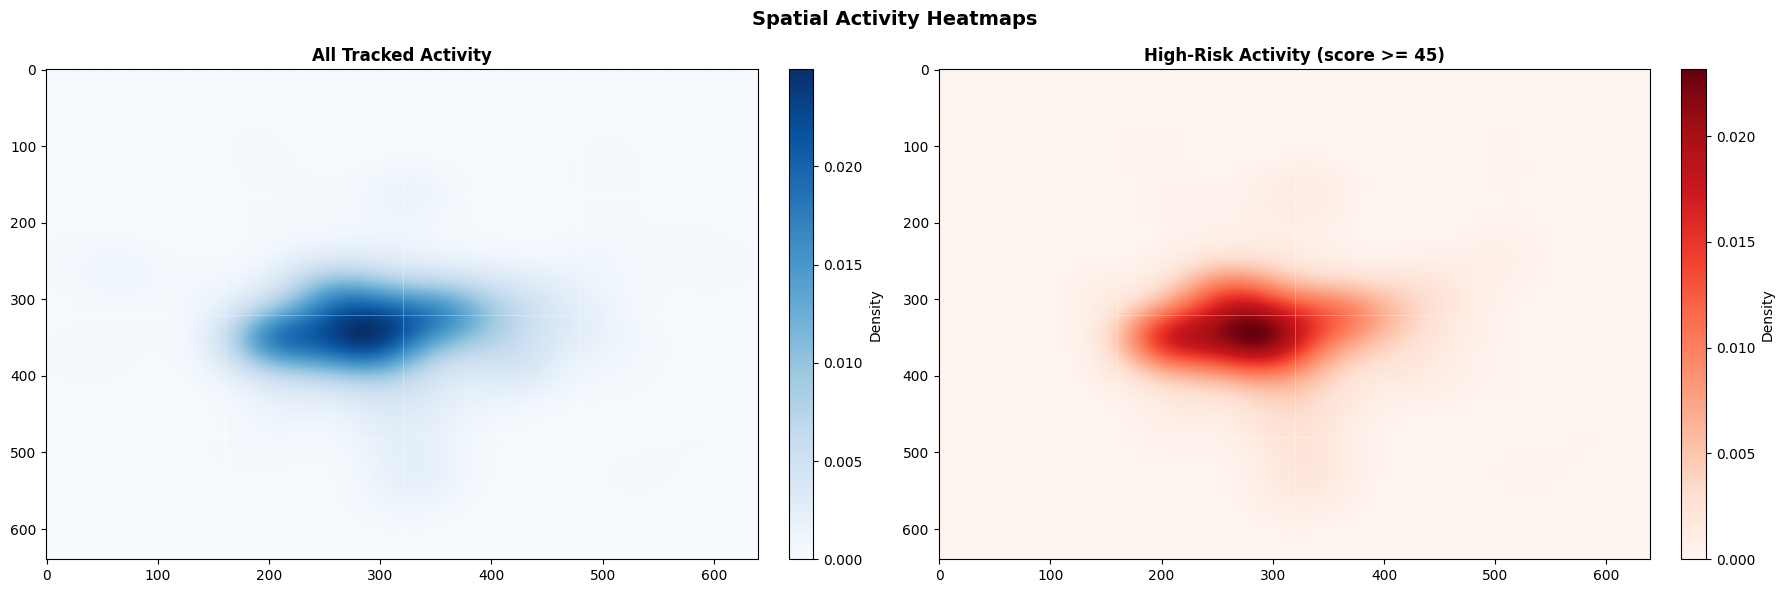

✅ Saved 02_spatial_heatmap.png


In [ ]:
fw = analysis_results[0]['frame_width']  if analysis_results else 1920
fh = analysis_results[0]['frame_height'] if analysis_results else 1080

all_heat    = np.zeros((fh, fw), dtype=np.float32)
threat_heat = np.zeros((fh, fw), dtype=np.float32)

for result in analysis_results:
    is_threat = result['risk_score'] >= 45
    for _, cx, cy in result['trajectory']:
        cx_c = max(0, min(fw-1, cx))
        cy_c = max(0, min(fh-1, cy))
        all_heat[cy_c, cx_c]    += 1
        if is_threat:
            threat_heat[cy_c, cx_c] += 1

all_heat    = gaussian_filter(all_heat,    sigma=30)
threat_heat = gaussian_filter(threat_heat, sigma=30)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Spatial Activity Heatmaps', fontsize=14, fontweight='bold')

for ax, heat, title, cmap in [
    (axes[0], all_heat,    'All Tracked Activity',           'Blues'),
    (axes[1], threat_heat, 'High-Risk Activity (score >= 45)', 'Reds'),
]:
    im = ax.imshow(heat, cmap=cmap, aspect='auto', interpolation='bilinear')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Density')
    ax.set_title(title, fontweight='bold')
    for row in range(1, ZONE_GRID_ROWS):
        ax.axhline(fh * row / ZONE_GRID_ROWS, color='white', lw=0.5, alpha=0.4)
    for col in range(1, ZONE_GRID_COLS):
        ax.axvline(fw * col / ZONE_GRID_COLS, color='white', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_spatial_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved 02_spatial_heatmap.png')


### 9.3 — Zone Threat Map


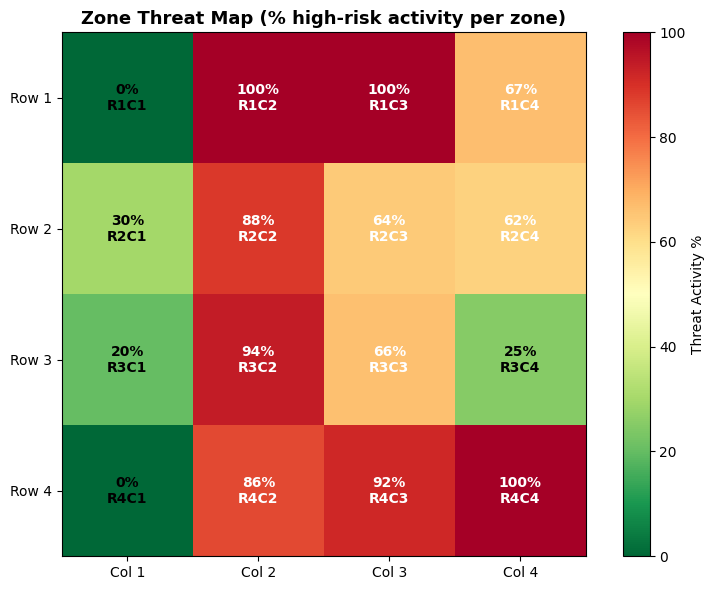

✅ Saved 03_zone_threat_map.png


In [ ]:
def assign_zone(cx, cy, fw, fh, rows, cols):
    row = min(int(cy / fh * rows), rows - 1)
    col = min(int(cx / fw * cols), cols - 1)
    return (row, col)

zone_total  = np.zeros((ZONE_GRID_ROWS, ZONE_GRID_COLS))
zone_threat = np.zeros((ZONE_GRID_ROWS, ZONE_GRID_COLS))

for result in analysis_results:
    is_threat = result['risk_score'] >= 45
    for _, cx, cy in result['trajectory']:
        r, c = assign_zone(cx, cy, fw, fh, ZONE_GRID_ROWS, ZONE_GRID_COLS)
        zone_total[r, c]  += 1
        if is_threat:
            zone_threat[r, c] += 1

with np.errstate(invalid='ignore', divide='ignore'):
    threat_pct = np.where(zone_total > 0, zone_threat / zone_total * 100, 0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(threat_pct, cmap='RdYlGn_r', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Threat Activity %')

for r in range(ZONE_GRID_ROWS):
    for c in range(ZONE_GRID_COLS):
        val = threat_pct[r, c]
        ax.text(c, r, f'{val:.0f}%\nR{r+1}C{c+1}',
                ha='center', va='center',
                color='white' if val > 60 else 'black',
                fontsize=10, fontweight='bold')

ax.set_title('Zone Threat Map (% high-risk activity per zone)',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(ZONE_GRID_COLS))
ax.set_yticks(range(ZONE_GRID_ROWS))
ax.set_xticklabels([f'Col {i+1}' for i in range(ZONE_GRID_COLS)])
ax.set_yticklabels([f'Row {i+1}' for i in range(ZONE_GRID_ROWS)])

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_zone_threat_map.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved 03_zone_threat_map.png')


### 9.4 — Class Transition Table


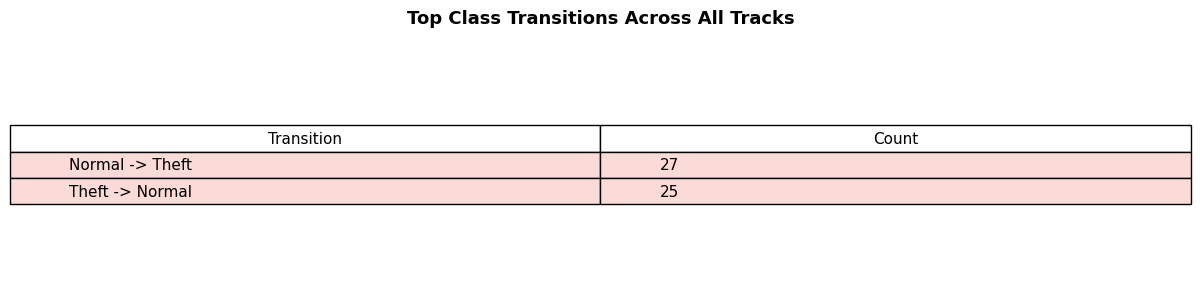

✅ Saved 04_class_transitions.png


In [ ]:
transition_counts = Counter()
for tid, profile in track_profiles.items():
    prev_cls = None
    for _, cls_name in profile['class_sequence']:
        if prev_cls is not None and prev_cls != cls_name:
            transition_counts[(prev_cls, cls_name)] += 1
        prev_cls = cls_name

top_transitions = transition_counts.most_common(20)

if top_transitions:
    table_data = [[f'{src} -> {tgt}', count] for (src, tgt), count in top_transitions]
    fig, ax = plt.subplots(figsize=(12, min(12, len(table_data) * 0.5 + 2)))
    ax.axis('off')
    ax.set_title('Top Class Transitions Across All Tracks',
                 fontsize=13, fontweight='bold', pad=20)
    tbl = ax.table(cellText=table_data, colLabels=['Transition', 'Count'],
                   loc='center', cellLoc='left')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.6)
    for i, row in enumerate(table_data):
        if 'Theft' in row[0]:
            tbl[(i+1, 0)].set_facecolor('#FADBD8')
            tbl[(i+1, 1)].set_facecolor('#FADBD8')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/04_class_transitions.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('✅ Saved 04_class_transitions.png')
else:
    print('No transitions found')


### 9.5 — Per-Track Behavior Timeline (Top 15 Riskiest)


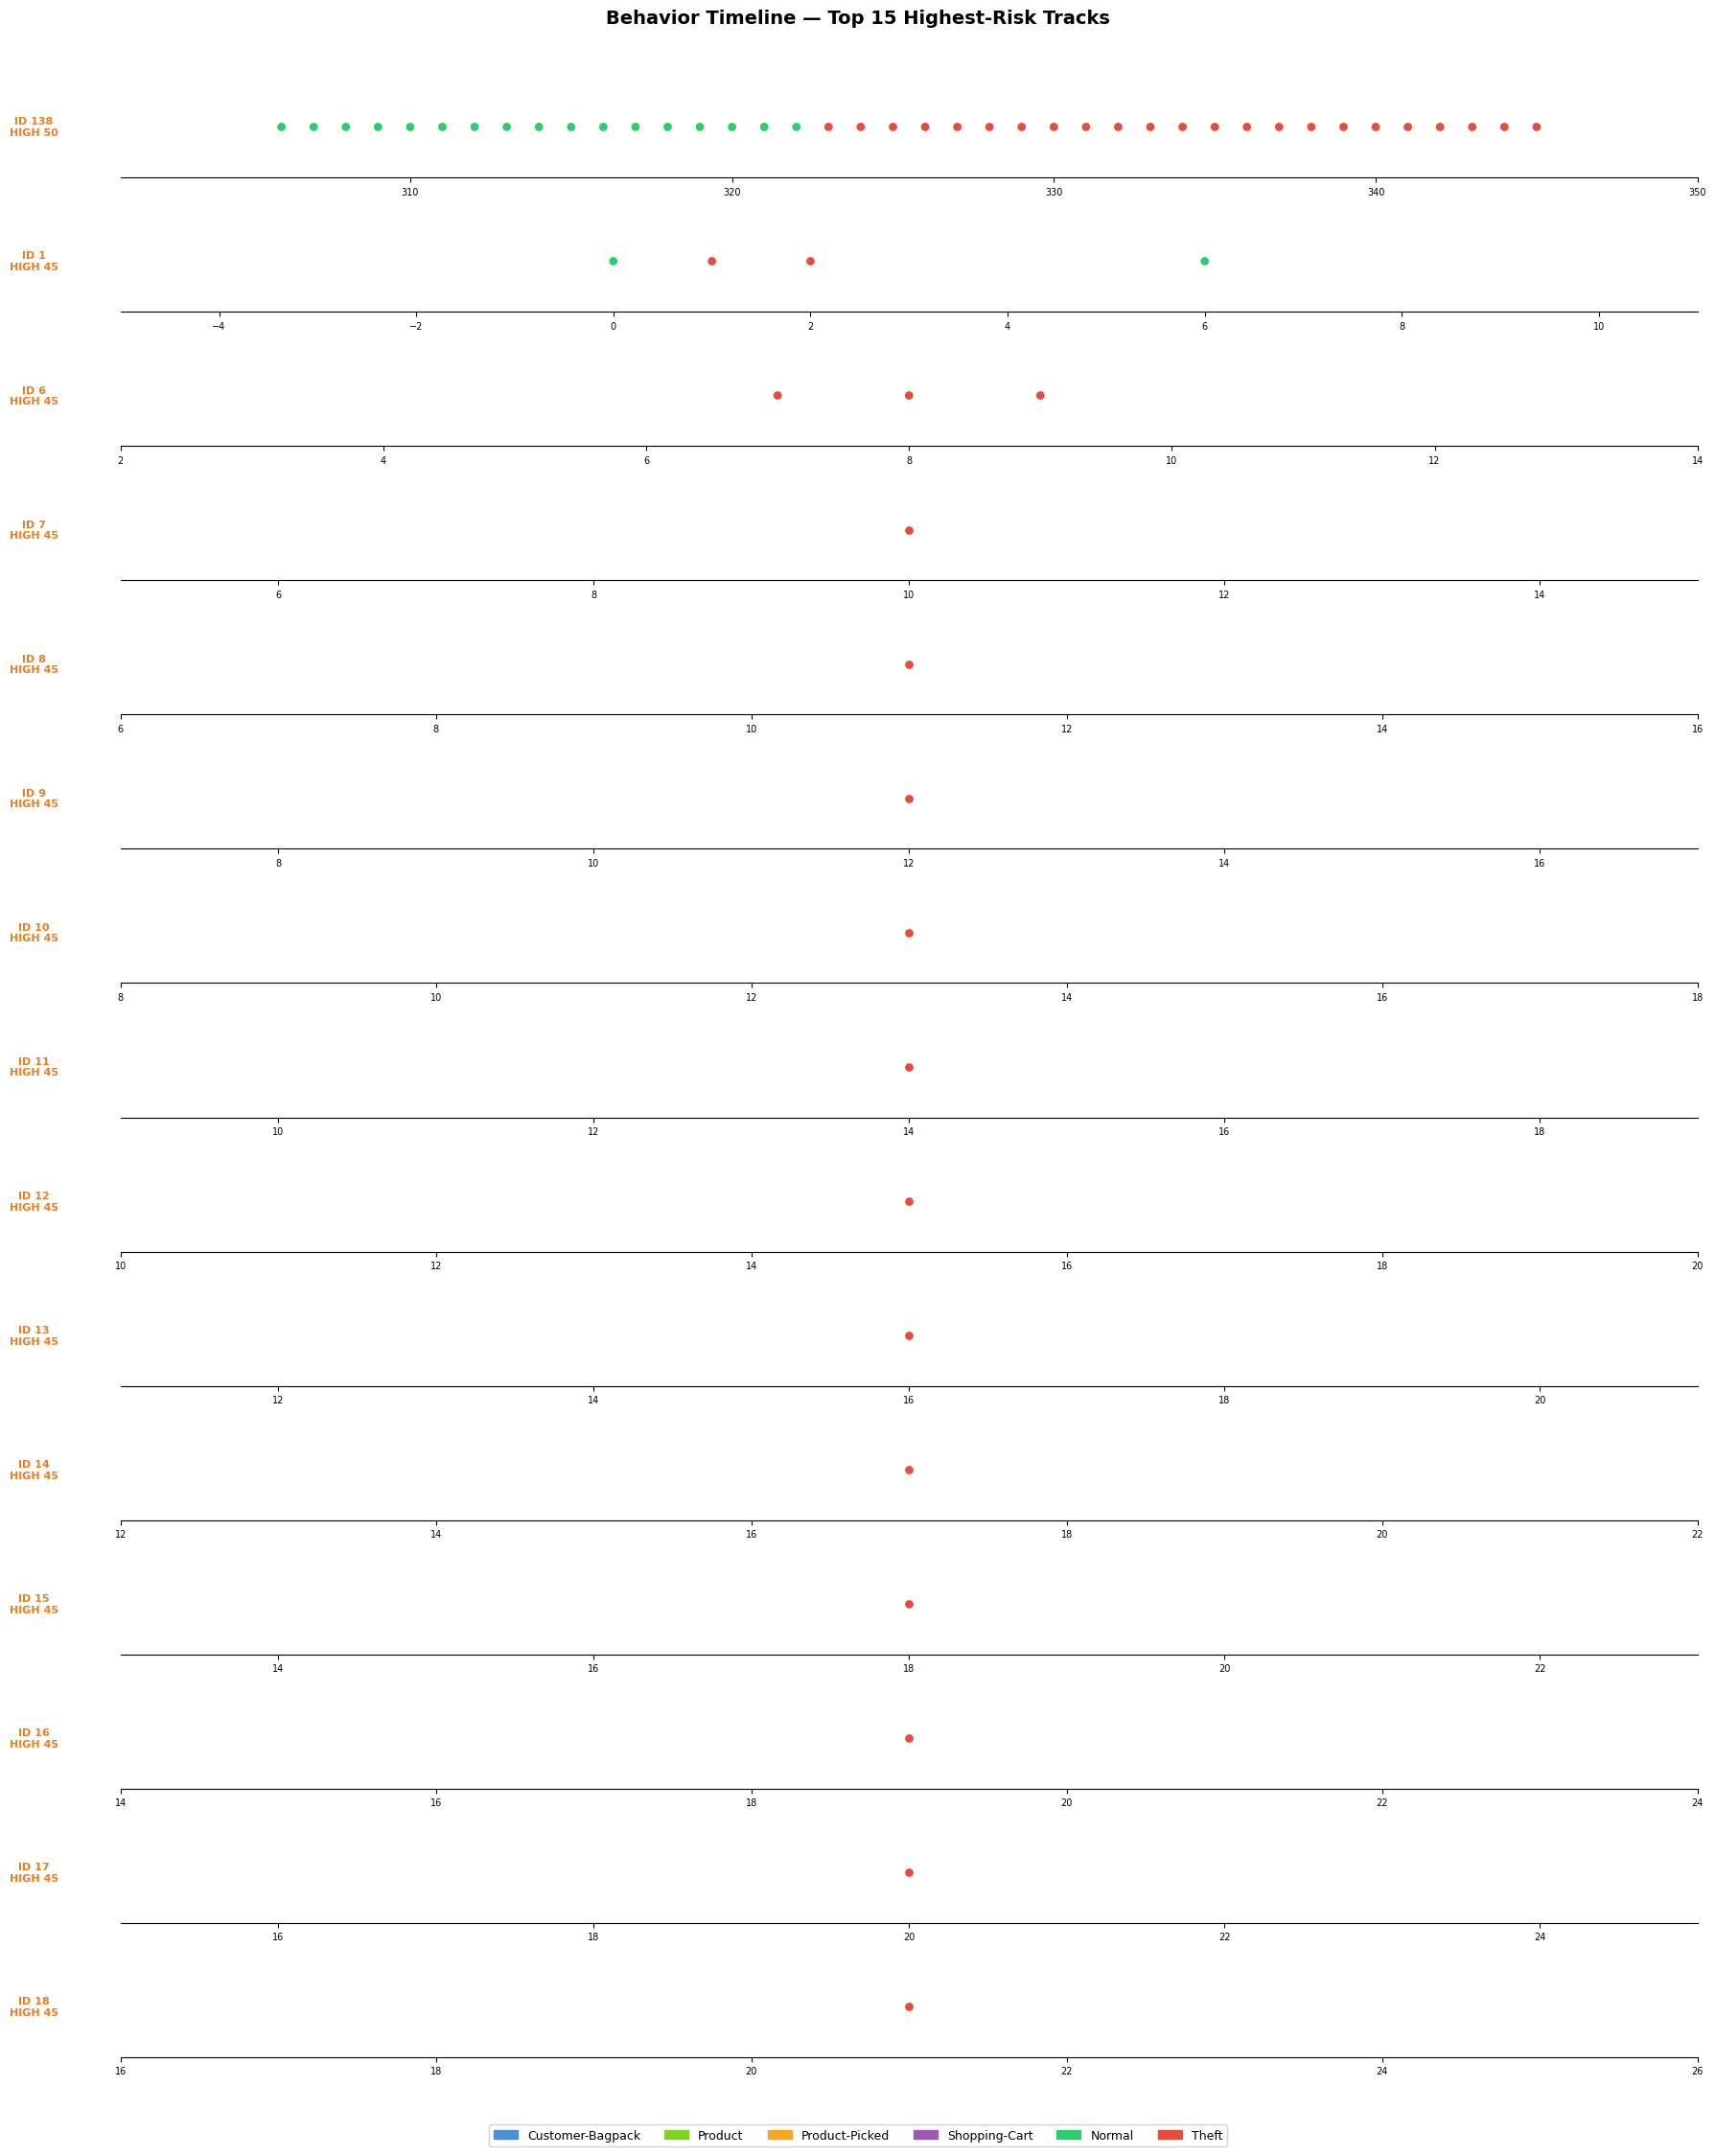

✅ Saved 05_behavior_timelines.png


In [ ]:
CLASS_INT = {v: k for k, v in CLASS_NAMES.items()}
top_n = min(15, len(analysis_results))
top_results = analysis_results[:top_n]

fig, axes = plt.subplots(top_n, 1, figsize=(18, top_n * 1.3 + 2))
if top_n == 1:
    axes = [axes]
fig.suptitle(f'Behavior Timeline — Top {top_n} Highest-Risk Tracks',
             fontsize=14, fontweight='bold', y=1.01)

for ax, result in zip(axes, top_results):
    tid     = result['track_id']
    profile = track_profiles[tid]
    seq     = profile['class_sequence']
    if not seq:
        continue
    frame_indices = [s[0] for s in seq]
    cls_ids       = [CLASS_INT.get(s[1], 0) for s in seq]
    colors        = [CLASS_COLORS.get(c, '#888') for c in cls_ids]
    ax.scatter(frame_indices, [0.5]*len(frame_indices),
               c=colors, s=40, zorder=3, linewidths=0)
    ax.set_yticks([])
    ax.set_xlim(min(frame_indices)-5, max(frame_indices)+5)
    ax.set_ylim(0, 1)
    risk_lbl = result['risk_level']
    risk_col = {'CRITICAL': '#C0392B', 'HIGH': '#E67E22',
                'MEDIUM': '#F1C40F', 'LOW': '#2ECC71'}.get(risk_lbl, 'grey')
    ax.set_ylabel(f'ID {tid}\n{risk_lbl} {result["risk_score"]}',
                  fontsize=8, rotation=0, labelpad=65,
                  va='center', color=risk_col, fontweight='bold')
    if result['theft_sequence'] and result['theft_stages']:
        for stage, fidx in result['theft_stages'].items():
            if fidx is not None:
                ax.axvline(fidx, color='#C0392B', lw=1, alpha=0.6, ls='--')
                ax.text(fidx, 0.85, stage[:4], fontsize=6,
                        ha='center', color='#C0392B', fontweight='bold')
    ax.spines[['top','right','left']].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)

legend_patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i])
                  for i in range(len(CLASS_NAMES))]
fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_behavior_timelines.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved 05_behavior_timelines.png')


---
## 10. Generate Alert Report


In [ ]:
from datetime import datetime

ALERT_THRESHOLD = 45
alerts = []

for result in analysis_results:
    if result['risk_score'] < ALERT_THRESHOLD:
        continue
    reasons = []
    if 'Theft' in result['classes_seen']:
        reasons.append('Theft class directly detected')
    if result['theft_sequence']:
        reasons.append('Theft sequence: Normal -> Product-Picked -> Theft')
    if result['concealment']:
        reasons.append(f'Concealment at frame {result["concealment_frame"]}')
    if result['loitering']:
        reasons.append(f'Loitering ({result["loiter_duration"]} frames)')
    if result['high_dwell']:
        reasons.append(f'Abnormal dwell time ({result["dwell_frames"]} frames)')

    alerts.append({
        'alert_id':    f'ALT-{len(alerts)+1:04d}',
        'timestamp':   datetime.now().isoformat(),
        'track_id':    result['track_id'],
        'risk_score':  result['risk_score'],
        'risk_level':  result['risk_level'],
        'sequence':    result['sequence_name'],
        'first_frame': result['first_frame'],
        'last_frame':  result['last_frame'],
        'dominant_class': result['dominant_class'],
        'classes_seen': result['classes_seen'],
        'reasons':     reasons,
        'recommended_action': (
            'IMMEDIATE INTERVENTION REQUIRED' if result['risk_level'] == 'CRITICAL'
            else 'Alert store security' if result['risk_level'] == 'HIGH'
            else 'Monitor closely'
        )
    })

# Save JSON + CSV
with open(f'{OUTPUT_DIR}/alerts.json', 'w') as f:
    json.dump(alerts, f, indent=2)

df_alerts = pd.DataFrame([{
    'alert_id': a['alert_id'], 'track_id': a['track_id'],
    'risk_score': a['risk_score'], 'risk_level': a['risk_level'],
    'sequence': a['sequence'], 'first_frame': a['first_frame'],
    'last_frame': a['last_frame'], 'dominant_class': a['dominant_class'],
    'reasons': ' | '.join(a['reasons']),
    'action': a['recommended_action']
} for a in alerts])
df_alerts.to_csv(f'{OUTPUT_DIR}/alerts.csv', index=False)

print(f'🚨 {len(alerts)} alerts generated')
print(f'   CRITICAL : {sum(1 for a in alerts if a["risk_level"]=="CRITICAL")}')
print(f'   HIGH     : {sum(1 for a in alerts if a["risk_level"]=="HIGH")}')
print(f'\n📋 Saved alerts.json + alerts.csv')

for a in alerts[:5]:
    print(f'\n  [{a["risk_level"]:8s}] Track {a["track_id"]}  Score:{a["risk_score"]}')
    for r in a['reasons']:
        print(f'     • {r}')


🚨 111 alerts generated
   CRITICAL : 0
   HIGH     : 111

📋 Saved alerts.json + alerts.csv

  [HIGH    ] Track 138  Score:50
     • Theft class directly detected
     • Loitering (30 frames)

  [HIGH    ] Track 1  Score:45
     • Theft class directly detected

  [HIGH    ] Track 6  Score:45
     • Theft class directly detected

  [HIGH    ] Track 7  Score:45
     • Theft class directly detected

  [HIGH    ] Track 8  Score:45
     • Theft class directly detected


---
## 11. Annotate & Preview Alert Frames


In [ ]:
ANNOTATE_MAX     = 20
ALERT_IMAGES_DIR = f'{OUTPUT_DIR}/alert_frames'
os.makedirs(ALERT_IMAGES_DIR, exist_ok=True)

def hex_to_bgr(hex_color):
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return (b, g, r)

BGRA_COLORS = {k: hex_to_bgr(v) for k, v in CLASS_COLORS.items()}
frame_idx_to_path = {i: p for i, p in enumerate(image_list)}

saved_count = 0
for alert in alerts[:ANNOTATE_MAX]:
    tid         = alert['track_id']
    target_fidx = alert['last_frame']
    img_path    = frame_idx_to_path.get(target_fidx)
    if img_path is None or not os.path.exists(img_path):
        continue
    frame = cv2.imread(img_path)
    if frame is None:
        continue
    H, W = frame.shape[:2]

    for entry in track_history.get(tid, []):
        if entry['frame_idx'] != target_fidx:
            continue
        x1, y1, x2, y2 = entry['x1'], entry['y1'], entry['x2'], entry['y2']
        color = BGRA_COLORS.get(entry['cls_id'], (128, 128, 128))
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
        label = f'ID:{tid} {alert["risk_level"]} {alert["risk_score"]}'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(frame, (x1, y1-th-10), (x1+tw+6, y1), color, -1)
        cv2.putText(frame, label, (x1+3, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1, cv2.LINE_AA)

    if alert['risk_level'] == 'CRITICAL':
        cv2.rectangle(frame, (0,0), (W,H), (0,0,200), 6)
        cv2.putText(frame, f'CRITICAL THREAT — Track {tid}',
                    (15, 45), cv2.FONT_HERSHEY_DUPLEX, 1.0, (0,0,255), 2)

    reasons_str = ' | '.join(alert['reasons'][:2])[:80]
    cv2.putText(frame, reasons_str, (15, H-15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 1)

    out_path = f'{ALERT_IMAGES_DIR}/{alert["alert_id"]}_track{tid}.jpg'
    cv2.imwrite(out_path, frame)
    saved_count += 1

print(f'✅ {saved_count} alert frames saved → {ALERT_IMAGES_DIR}')


✅ 20 alert frames saved → /content/behavior_analysis/alert_frames


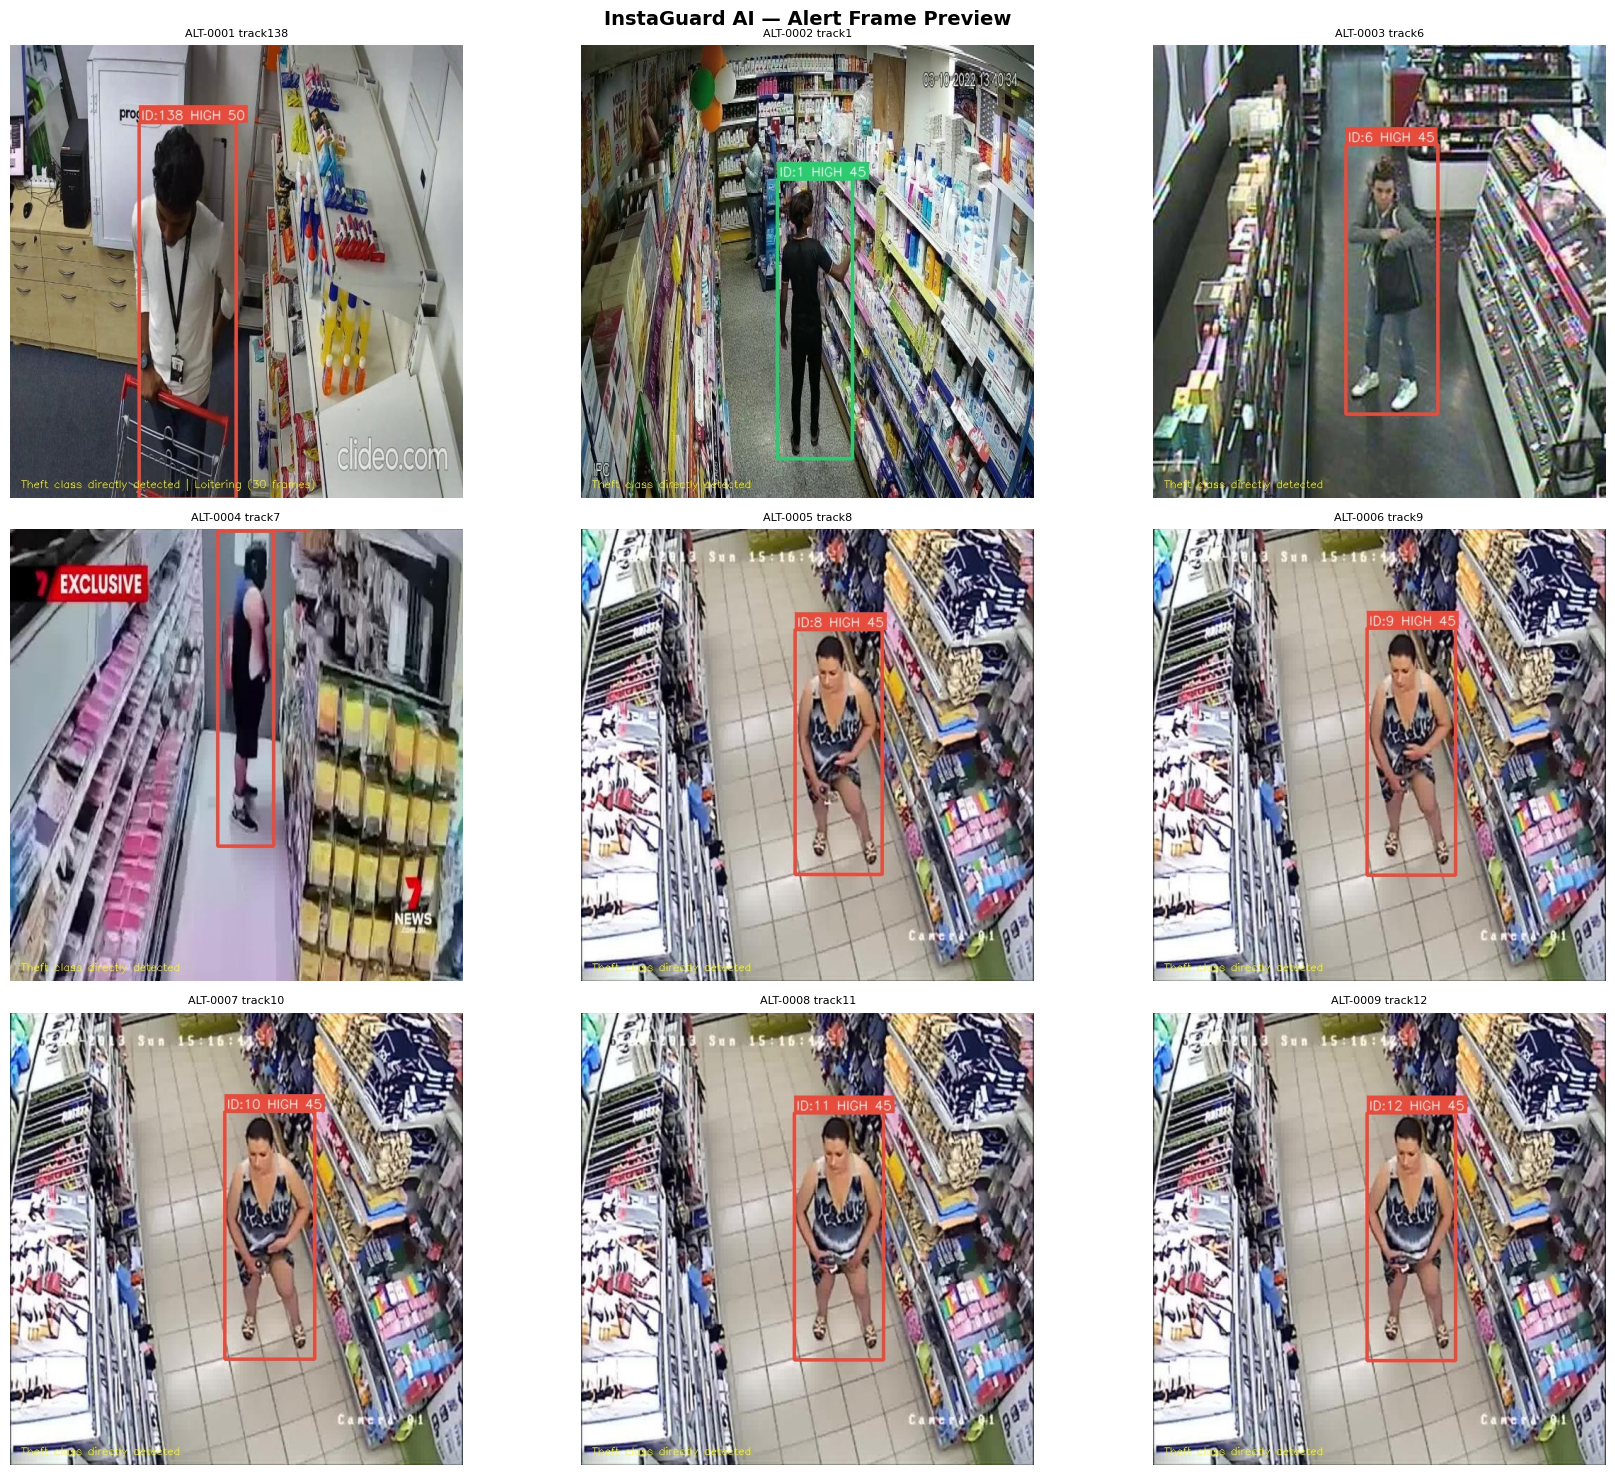

✅ Saved 06_alert_preview_grid.png


In [ ]:
# Preview grid
alert_files = sorted(os.listdir(ALERT_IMAGES_DIR))
if not alert_files:
    print('No alert frames generated — lower ALERT_THRESHOLD if needed')
else:
    cols  = 3
    n     = min(9, len(alert_files))
    rows  = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()
    for ax, fname in zip(axes, alert_files[:n]):
        img = cv2.imread(os.path.join(ALERT_IMAGES_DIR, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(fname.replace('_',' ').replace('.jpg',''), fontsize=8)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle('InstaGuard AI — Alert Frame Preview', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/06_alert_preview_grid.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Saved 06_alert_preview_grid.png')


---
## 12. Save All Results to Google Drive


In [ ]:
import shutil

DRIVE_OUTPUT = '/content/drive/MyDrive/instaguard_behavior_analysis'  # ✏️
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

files_to_copy = [
    (f'{OUTPUT_DIR}/01_behavior_overview.png',   '01_behavior_overview.png'),
    (f'{OUTPUT_DIR}/02_spatial_heatmap.png',      '02_spatial_heatmap.png'),
    (f'{OUTPUT_DIR}/03_zone_threat_map.png',       '03_zone_threat_map.png'),
    (f'{OUTPUT_DIR}/04_class_transitions.png',     '04_class_transitions.png'),
    (f'{OUTPUT_DIR}/05_behavior_timelines.png',    '05_behavior_timelines.png'),
    (f'{OUTPUT_DIR}/06_alert_preview_grid.png',    '06_alert_preview_grid.png'),
    (f'{OUTPUT_DIR}/alerts.json',                  'alerts.json'),
    (f'{OUTPUT_DIR}/alerts.csv',                   'alerts.csv'),
]

for src, dst_name in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, os.path.join(DRIVE_OUTPUT, dst_name))
        print(f'✅ {dst_name}')
    else:
        print(f'⚠️  Not found: {src}')

if os.path.exists(ALERT_IMAGES_DIR):
    dst = os.path.join(DRIVE_OUTPUT, 'alert_frames')
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(ALERT_IMAGES_DIR, dst)
    print(f'✅ alert_frames/ ({len(os.listdir(dst))} images)')

print(f'\n📁 All results saved to: {DRIVE_OUTPUT}')


✅ 01_behavior_overview.png
✅ 02_spatial_heatmap.png
✅ 03_zone_threat_map.png
✅ 04_class_transitions.png
✅ 05_behavior_timelines.png
✅ 06_alert_preview_grid.png
✅ alerts.json
✅ alerts.csv
✅ alert_frames/ (20 images)

📁 All results saved to: /content/drive/MyDrive/instaguard_behavior_analysis


In [ ]:
import shutil
from google.colab import files

# Zip everything and download directly
shutil.make_archive('/content/instaguard_results', 'zip',
                    '/content/drive/MyDrive/instaguard_behavior_analysis')
files.download('/content/instaguard_results.zip')
print('⬇️ Downloading all results as ZIP!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Downloading all results as ZIP!


In [ ]:
import os

folder = '/content/drive/MyDrive/instaguard_behavior_analysis'

for f in sorted(os.listdir(folder)):
    if f.endswith('.csv') or f.endswith('.json'):
        print(f)

alerts.csv
alerts.json


---
## 📝 Summary

### Risk Score Formula
```
Risk Score (0-100) = sum of triggered weights:
  +45 pts  Theft class directly observed
  +20 pts  Product-Picked without Shopping-Cart
  +20 pts  Full theft sequence (Normal → Product-Picked → Theft)
  +10 pts  Concealment (product disappears after Product-Picked)
  + 5 pts  Loitering (track stays in same spot for 30+ frames)

CRITICAL >= 70  |  HIGH >= 45  |  MEDIUM >= 20  |  LOW < 20
```

### Output Files
| File | Description |
|------|-------------|
| `01_behavior_overview.png` | Risk distribution, flags, score histogram |
| `02_spatial_heatmap.png` | All activity vs. high-risk heatmaps |
| `03_zone_threat_map.png` | Grid zone threat % map |
| `04_class_transitions.png` | Top class-to-class transitions |
| `05_behavior_timelines.png` | Per-track class history timeline |
| `06_alert_preview_grid.png` | Annotated alert frame preview |
| `alerts.json` | Full structured alert log |
| `alerts.csv` | Tabular alert log for reporting |
| `alert_frames/` | Annotated JPG for each triggered alert |
